In [1]:
from src.measure_ir import *
import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.fxlms import FxLMS

In [2]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(fs)

In [3]:
target, ref = ad.play(source_out=arthur)

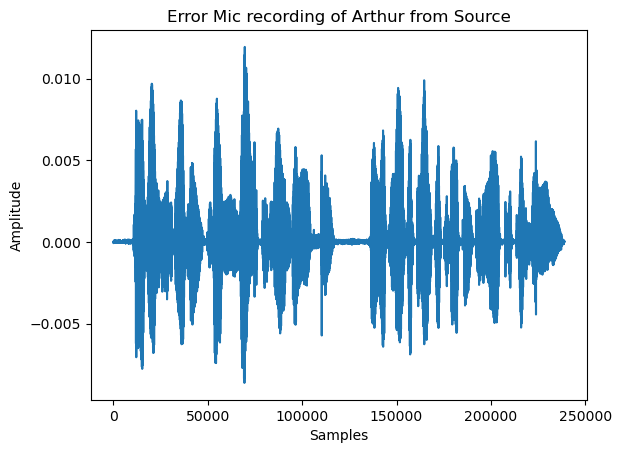

In [4]:
plt.plot(target)
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Error Mic recording of Arthur from Source')
plt.show()

In [5]:
error_ir, _ = measure_ir(ad)

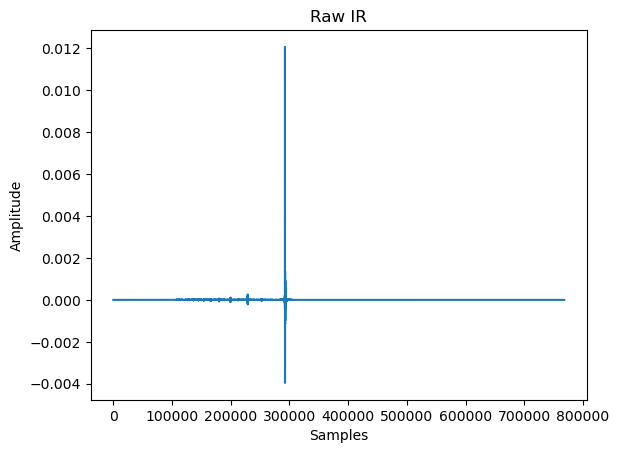

In [6]:
plt.plot(error_ir)
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Raw IR')
plt.show()

In [7]:
ir_len = 128
panel_to_err_cm = 7
filter_order = 2 * ir_len
step_fn = lambda t: max(1e-5, 0.7 * np.exp(-t / 5))

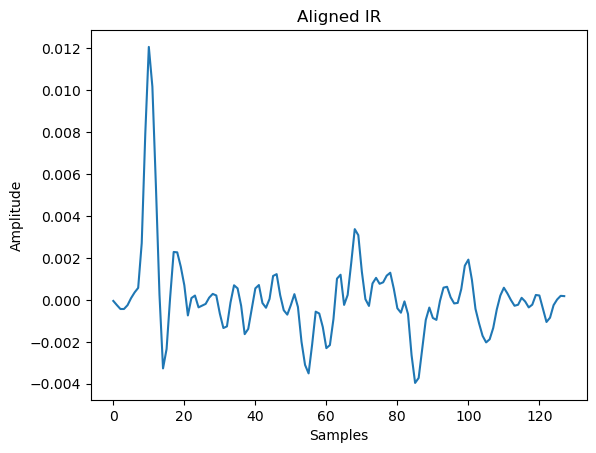

In [8]:
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)
plt.plot(panel_ir)

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IR')
plt.show()

Final MSE: 6.981e-08
Lowest MSE: 6.981e-08


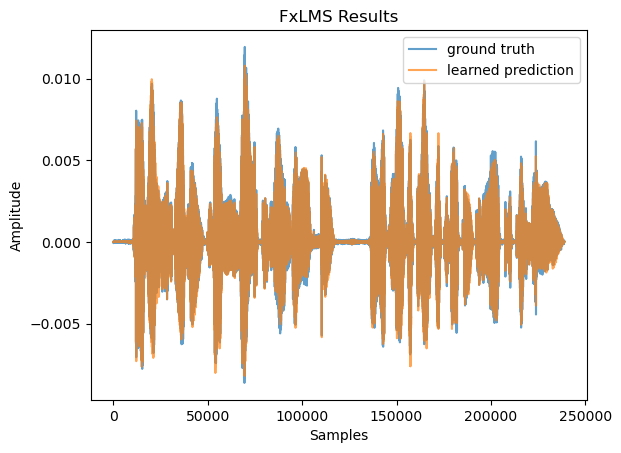

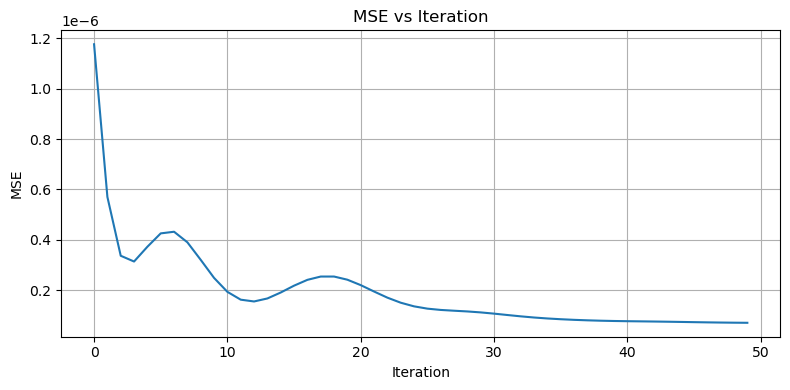

In [14]:
n_iter = 50
fx = FxLMS(ref, target, panel_ir, filter_order, step_fn, use_norm=True)
fx.learn(n_iter)

In [10]:
error_mic, _ = ad.play(panel_out=fx.pred, source_out=arthur)

No Cancel RMS: 0.001562
Cancel RMS: 0.001864


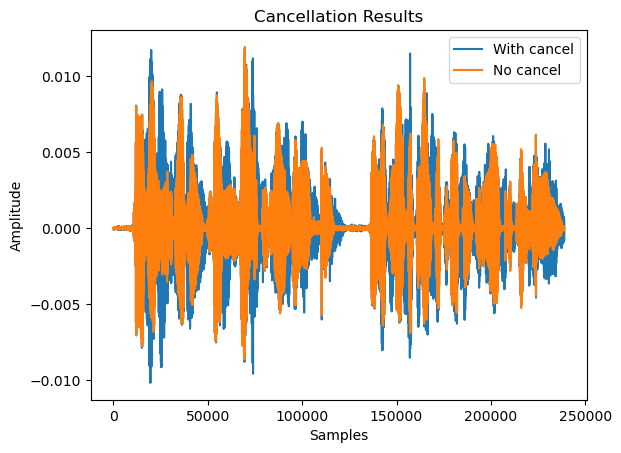

In [13]:
rms_nc = np.sqrt(np.mean(target**2))
rms_cancel = np.sqrt(np.mean(error_mic**2))

print(f'No Cancel RMS: {rms_nc:.6f}')
print(f'Cancel RMS: {rms_cancel:.6f}')

plt.plot(error_mic, label="With cancel")
plt.plot(target, label="No cancel")
plt.legend()
plt.title('Cancellation Results')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()